# Prueba de Hipótesis 1: Comparación de diámetros entre especies de árboles
## Prueba de Kruskal-Wallis

In [14]:
# Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [15]:
# Carga de datos
df = pd.read_csv('../data/datos_arbolado_clean.csv')

# Visualización de las primeras filas e información básica
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Dimensiones del dataset: (338991, 14)

Primeras filas:


,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200.0,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450.0,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480.0,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
3,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700.0,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
4,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620.0,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


In [16]:
# Información sobre las variables de interés
print("Información sobre las variables clave:")
print(f"Diámetro promedio: {df['diametro_altura_pecho'].mean():.2f} cm")
print(f"Diámetro mediano: {df['diametro_altura_pecho'].median():.2f} cm")
print(f"Número de especies únicas: {df['nombre_cientifico'].nunique()}")

print("\nEspecies más frecuentes:")
especies_counts = df['nombre_cientifico'].value_counts()
print(especies_counts.head(10))

Información sobre las variables clave:
Diámetro promedio: 32.68 cm
Diámetro mediano: 29.00 cm
Número de especies únicas: 15

Especies más frecuentes:
nombre_cientifico
Fraxinus pennsylvanica    127973
Otra                       54172
Platanus x acerifolia      29960
Ficus benjamina            21379
Tilia x moltkei            14800
Melia azedarach            14036
Jacaranda mimosifolia      12790
Lagerstroemia indica       11356
Fraxinus americana          9621
Ligustrum lucidum           8624
Name: count, dtype: int64


In [17]:
# Selección de especies con al menos 10 observaciones para una mejor fiabilidad estadística
especies_frecuentes = especies_counts[especies_counts >= 10].index
df_filtrado = df[df['nombre_cientifico'].isin(especies_frecuentes)]

print(f"Número de especies retenidas: {len(especies_frecuentes)}")
print(f"Número total de observaciones: {len(df_filtrado)}")
print("\nEspecies retenidas:")
print(especies_frecuentes.tolist())

Número de especies retenidas: 15
Número total de observaciones: 338991

Especies retenidas:
['Fraxinus pennsylvanica', 'Otra', 'Platanus x acerifolia', 'Ficus benjamina', 'Tilia x moltkei', 'Melia azedarach', 'Jacaranda mimosifolia', 'Lagerstroemia indica', 'Fraxinus americana', 'Ligustrum lucidum', 'Fraxinus excelsior', 'Tipuana tipu', 'Ligustrum lucidum f. aureovariegata', 'Liquidambar styraciflua', 'Acer negundo']


In [18]:
# Estadísticas descriptivas por especie
print("ESTADÍSTICAS DESCRIPTIVAS POR ESPECIE")
print("=" * 50)

stats_especies = df_filtrado.groupby('nombre_cientifico')['diametro_altura_pecho'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

stats_especies_sorted = stats_especies.sort_values('mean', ascending=False)
stats_especies_sorted

ESTADÍSTICAS DESCRIPTIVAS POR ESPECIE


,count,mean,median,std,min,max
nombre_cientifico,,,,,,
Platanus x acerifolia,29960,61.14,62.0,19.69,2.0,149.0
Melia azedarach,14036,55.22,57.0,21.25,2.0,149.0
Tipuana tipu,8125,53.69,57.0,24.59,2.0,144.0
Acer negundo,4892,35.76,36.0,17.44,2.0,143.0
Ficus benjamina,21379,34.64,30.0,22.12,2.0,148.0
Fraxinus pennsylvanica,127973,31.31,30.0,14.30,2.0,149.0
Fraxinus americana,9621,30.97,30.0,14.83,2.0,120.0
Fraxinus excelsior,8201,29.61,28.0,13.78,2.0,137.0
Tilia x moltkei,14800,26.14,26.0,13.44,2.0,132.0


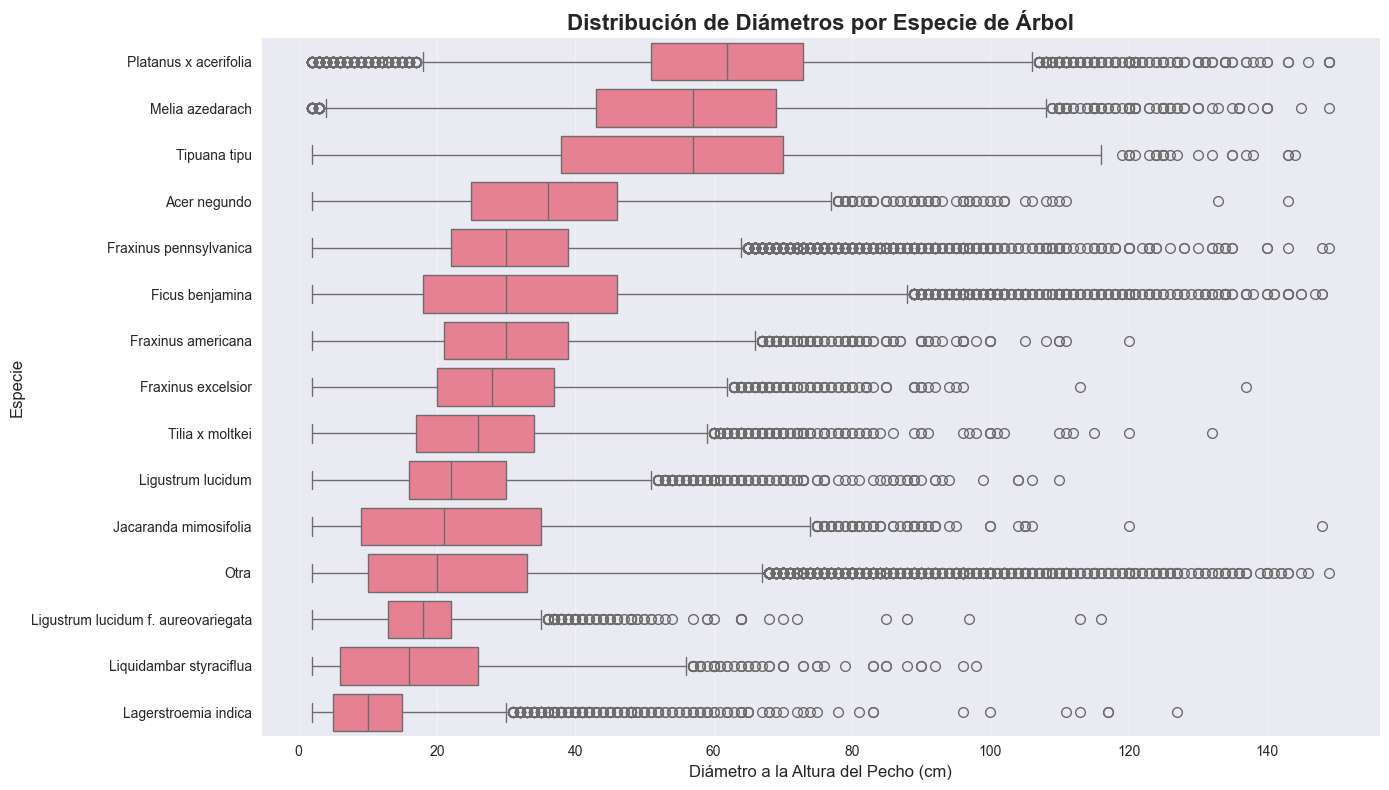

In [19]:
# Visualización 1: Boxplot de los diámetros por especie
plt.figure(figsize=(14, 8))

# Ordenar por diámetro mediano
especies_ordenadas = df_filtrado.groupby('nombre_cientifico')['diametro_altura_pecho'].median().sort_values(ascending=False).index

sns.boxplot(data=df_filtrado, 
            x='diametro_altura_pecho', 
            y='nombre_cientifico',
            order=especies_ordenadas)

plt.title('Distribución de Diámetros por Especie de Árbol', fontsize=16, fontweight='bold')
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Especie', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

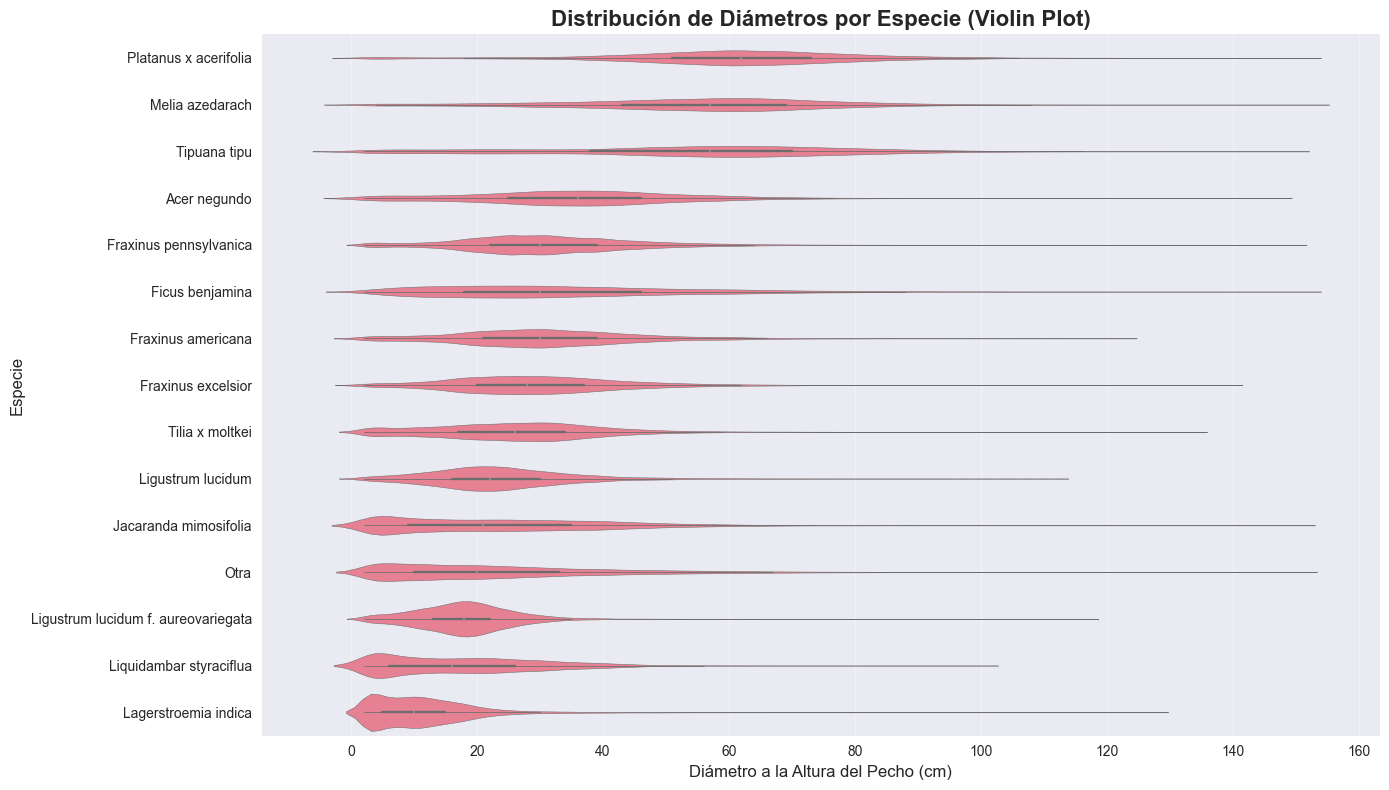

In [20]:
# Visualización 2: Violin plot para ver la densidad de distribución
plt.figure(figsize=(14, 8))

sns.violinplot(data=df_filtrado, 
               x='diametro_altura_pecho', 
               y='nombre_cientifico',
               order=especies_ordenadas)

plt.title('Distribución de Diámetros por Especie (Violin Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Especie', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Preparación de datos para la prueba de Kruskal-Wallis
grupos = []
for especie in especies_frecuentes:
    grupo = df_filtrado[df_filtrado['nombre_cientifico'] == especie]['diametro_altura_pecho']
    grupos.append(grupo)

print(f"Número de grupos (especies) para la prueba: {len(grupos)}")
print(f"Tamaños de los grupos: {[len(g) for g in grupos]}")

Número de grupos (especies) para la prueba: 15
Tamaños de los grupos: [127973, 54172, 29960, 21379, 14800, 14036, 12790, 11356, 9621, 8624, 8201, 8125, 7751, 5311, 4892]


In [22]:
# Prueba de Kruskal-Wallis
print("PRUEBA DE KRUSKAL-WALLIS")
print("=" * 40)

statistic, p_value = stats.kruskal(*grupos)

print(f"Estadística H de Kruskal-Wallis: {statistic:.4f}")
print(f"Valor p: {p_value:.10f}")
print(f"Valor p (notación científica): {p_value:.2e}")

# Interpretación
alpha = 0.05
print("\nINTERPRETACIÓN:")
print("-" * 20)
if p_value < alpha:
    print(f"✓ Se rechaza la hipótesis nula (p-value < {alpha})")
    print("✓ Existen diferencias estadísticamente significativas entre los diámetros de las diferentes especies de árboles")
else:
    print(f"✗ No se puede rechazar la hipótesis nula (p-value ≥ {alpha})")
    print("✗ No hay diferencias estadísticamente significativas entre los diámetros de las diferentes especies")

PRUEBA DE KRUSKAL-WALLIS
Estadística H de Kruskal-Wallis: 103879.2616
Valor p: 0.0000000000
Valor p (notación científica): 0.00e+00

INTERPRETACIÓN:
--------------------
✓ Se rechaza la hipótesis nula (p-value < 0.05)
✓ Existen diferencias estadísticamente significativas entre los diámetros de las diferentes especies de árboles


In [23]:
# Prueba de normalidad (Shapiro-Wilk) sobre los residuos para verificar los supuestos
print("\nPRUEBA DE NORMALIDAD (SHAPIRO-WILK) SOBRE LOS DIÁMETROS")
print("=" * 55)

# Prueba sobre el conjunto de datos
stat_shapiro, p_shapiro = stats.shapiro(df_filtrado['diametro_altura_pecho'])
print(f"Prueba de Shapiro-Wilk sobre todos los diámetros:")
print(f"  Estadística: {stat_shapiro:.4f}")
print(f"  Valor p: {p_shapiro:.10f}")

if p_shapiro < 0.05:
    print("  ✓ Los datos no siguen una distribución normal")
    print("  ✓ La prueba de Kruskal-Wallis es apropiada")
else:
    print("  ✗ Los datos podrían seguir una distribución normal")


PRUEBA DE NORMALIDAD (SHAPIRO-WILK) SOBRE LOS DIÁMETROS
Prueba de Shapiro-Wilk sobre todos los diámetros:
  Estadística: 0.9461
  Valor p: 0.0000000000
  ✓ Los datos no siguen una distribución normal
  ✓ La prueba de Kruskal-Wallis es apropiada


c:\Users\Augus\Documents\Cours UNICEN\ciensas de datos\TP-Ciencia-De-Datos-Grupo14\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 338991.
  res = hypotest_fun_out(*samples, **kwds)


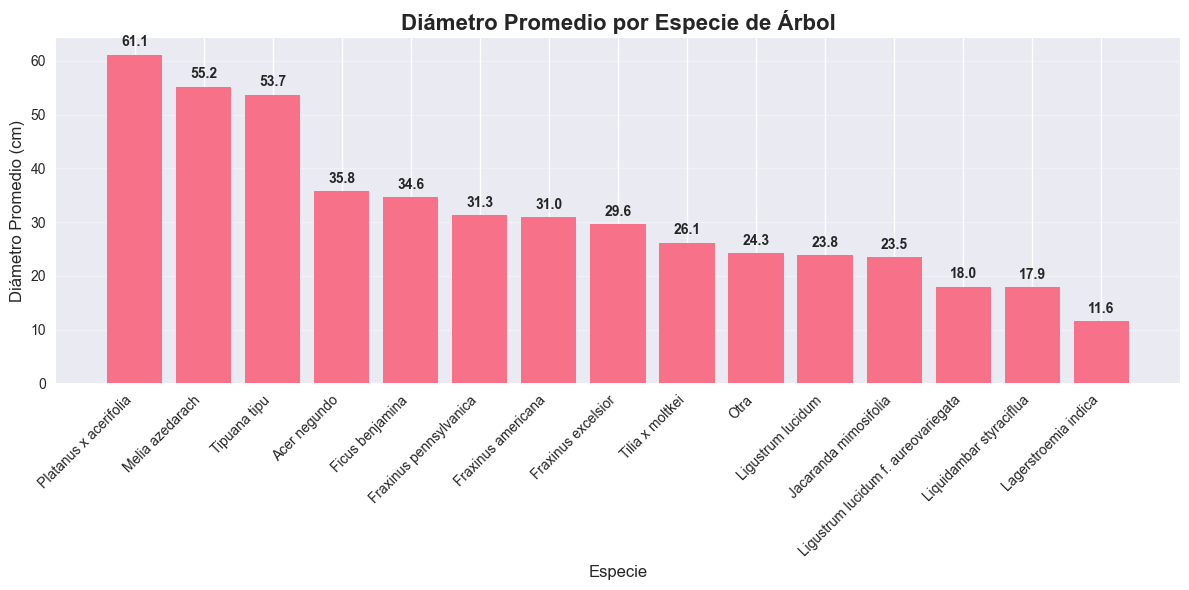

In [25]:
# Visualización de las diferencias con un gráfico de barras de los diámetros promedios
plt.figure(figsize=(12, 6))

diametros_medios = df_filtrado.groupby('nombre_cientifico')['diametro_altura_pecho'].mean().sort_values(ascending=False)

bars = plt.bar(range(len(diametros_medios)), diametros_medios.values)
plt.xticks(range(len(diametros_medios)), diametros_medios.index, rotation=45, ha='right')

# Adición de valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title('Diámetro Promedio por Especie de Árbol', fontsize=16, fontweight='bold')
plt.ylabel('Diámetro Promedio (cm)', fontsize=12)
plt.xlabel('Especie', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Resumen de resultados
print("RESUMEN DE RESULTADOS")
print("=" * 30)
print(f"• Hipótesis probada: Los diámetros difieren según las especies de árboles")
print(f"• Prueba utilizada: Kruskal-Wallis (no paramétrica)")
print(f"• Número de especies comparadas: {len(especies_frecuentes)}")
print(f"• Resultado de la prueba: {'SIGNIFICATIVO' if p_value < alpha else 'NO SIGNIFICATIVO'}")
print(f"• P-value: {p_value:.2e}")
print(f"• Especie con mayor diámetro promedio: {diametros_medios.index[0]} ({diametros_medios.iloc[0]:.1f} cm)")
print(f"• Especie con menor diámetro promedio: {diametros_medios.index[-1]} ({diametros_medios.iloc[-1]:.1f} cm)")

if p_value < alpha:
    print("\nCONCLUSIÓN: Existen diferencias significativas en los diámetros según las especies.")
    print("Esto podría explicarse por diferencias en:")
    print("  - La velocidad de crecimiento de las especies")
    print("  - La edad de los árboles plantados")
    print("  - Las condiciones de crecimiento")
else:
    print("\nCONCLUSIÓN: No se detectó ninguna diferencia significativa entre las especies.")

RESUMEN DE RESULTADOS
• Hipótesis probada: Los diámetros difieren según las especies de árboles
• Prueba utilizada: Kruskal-Wallis (no paramétrica)
• Número de especies comparadas: 15
• Resultado de la prueba: SIGNIFICATIVO
• P-value: 0.00e+00
• Especie con mayor diámetro promedio: Platanus x acerifolia (61.1 cm)
• Especie con menor diámetro promedio: Lagerstroemia indica (11.6 cm)

CONCLUSIÓN: Existen diferencias significativas en los diámetros según las especies.
Esto podría explicarse por diferencias en:
  - La velocidad de crecimiento de las especies
  - La edad de los árboles plantados
  - Las condiciones de crecimiento
